# Informe Ejecutivo Actuarial: Tarificación MTPL
## Fase 2: Modelado Predictivo de Severidad y Frecuencia

Este documento contiene la segunda etapa del análisis de la cartera de automóviles `freMTPL2`. Una vez concluida la extracción, limpieza y el Análisis Exploratorio de Datos (EDA) en el entorno de R, procedemos al modelado estadístico riguroso en Python.

### 1. Justificación del Entorno Tecnológico y Librerías
El uso de Python para esta fase obedece a la capacidad de sus librerías para combinar inferencia estadística tradicional con algoritmos modernos de partición espacial:

* **`pandas` y `numpy`**: Motores de álgebra lineal y manipulación matricial.
* **`statsmodels`**: Motor de inferencia estadística. Permite ajustar Modelos Lineales Generalizados (GLM) calculando la matriz de información de Fisher para obtener errores estándar, estadísticos de Wald ($z$) y p-valores exactos.
* **`scikit-learn`**: Ecosistema algorítmico. Utilizaremos `HistGradientBoostingRegressor`, una implementación de *Gradient Boosting Machine* basada en la construcción aditiva de árboles de decisión. Es matemáticamente óptima porque minimiza directamente la devianza funcional (Gamma o Poisson) y maneja interacciones multivariadas sin necesidad de que el actuario especifique la forma funcional explícitamente.
* **`matplotlib` y `seaborn`**: Librerías para la visualización de la validación actuarial (Gráficos Actual vs Expected y Curvas de Lift).

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_gamma_deviance, mean_poisson_deviance, mean_absolute_error, mean_squared_error

# Librerías para visualización gráfica en Python
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo estético para las gráficas
sns.set_theme(style="whitegrid")

### 2. Preparación Estructural de los Datos
Para garantizar la convergencia matemática de los algoritmos de Máxima Verosimilitud (GLM) y del Descenso de Gradiente, aplicamos transformaciones clave sobre los datos exportados:

1. **Linealización Logarítmica (`LogDensity`)**: La densidad poblacional urbana presenta una asimetría extrema (exceso de concentración). Su transformación logarítmica estabiliza la varianza y permite un ajuste lineal eficiente.
2. **Truncamiento de Valores Extremos (`clip`)**: En la base de frecuencia, topamos matemáticamente el número de siniestros a 4 por año-póliza. En la teoría del riesgo MTPL, una frecuencia observada mayor suele obedecer a un riesgo atípico (fraude o flota comercial erróneamente clasificada como riesgo individual) que distorsionaría severamente la estimación del parámetro $\lambda$.

In [2]:
# --- PREPARACIÓN PARA SEVERIDAD ---
df_sev = pd.read_csv("df_sev_positiva_export.csv")
columnas_categoricas = ['VehBrand', 'VehGas', 'Region']

for col in columnas_categoricas:
    df_sev[col] = df_sev[col].astype('category')

df_sev['LogDensity'] = np.log10(df_sev['Density'] + 1)
df_train_sev, df_test_sev = train_test_split(df_sev, test_size=0.20, random_state=42)

# --- PREPARACIÓN PARA FRECUENCIA ---
df_freq = pd.read_csv("df_completo_export.csv")

for col in columnas_categoricas:
    df_freq[col] = df_freq[col].astype('category')

df_freq['LogDensity'] = np.log10(df_freq['Density'] + 1)
df_freq['ClaimNb'] = df_freq['ClaimNb'].clip(upper=4) # Control de outliers extremos
df_train_freq, df_test_freq = train_test_split(df_freq, test_size=0.20, random_state=42)

# Definición estándar del vector de características predictivas (Matriz X)
features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'LogDensity', 'VehBrand', 'VehGas']

### 3. Modelado de la Severidad Estocástica ($X$)
La severidad condicionada ($X | N > 0$) describe el costo del reclamo dado que un accidente ocurrió. Se modela asumiendo que los costos siguen una **Distribución Gamma**.

**Fundamento Estadístico:**
La distribución Gamma tiene un dominio en $(0, \infty)$ y asume que la varianza es proporcional al cuadrado de la media: $Var(X) = \phi \mu^2$. Esta propiedad es crítica para capturar el sesgo positivo extremo (las "colas pesadas") que generan los siniestros catastróficos.
Empleamos una **función de enlace logarítmica** ($\ln(\mu) = \mathbf{X}\beta$) para asegurar matemáticamente que la proyección de la prima pura resultante sea estrictamente positiva, cumpliendo el axioma de no arbitraje.

In [3]:
# MODELO 1: GLM Gamma con Enlace Logarítmico
formula_sev = "TotalClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + LogDensity + C(VehBrand) + C(VehGas)"

modelo_sev_glm = smf.glm(formula=formula_sev, 
                         data=df_train_sev, 
                         family=sm.families.Gamma(link=sm.families.links.Log()))

resultado_sev_glm = modelo_sev_glm.fit()

print("================ REPORTE GLM SEVERIDAD (GAMMA) ================")
print(resultado_sev_glm.summary())

================ REPORTE GLM SEVERIDAD (GAMMA) ================
                 Generalized Linear Model Regression Results                  
Dep. Variable:       TotalClaimAmount   No. Observations:                19955
Model:                            GLM   Df Residuals:                    19938
Model Family:                   Gamma   Df Model:                           16
Link Function:                    Log   Scale:                          60.600
Method:                          IRLS   Log-Likelihood:            -2.2128e+05
Date:                Sat, 28 Feb 2026   Deviance:                       34046.
Time:                        14:28:47   Pearson chi2:                 1.21e+06
No. Iterations:                    48   Pseudo R-squ. (CS):           0.001606
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [4]:
# MODELO 2: HistGradientBoosting (No Paramétrico)
X_train_sev = df_train_sev[features]
y_train_sev = df_train_sev['TotalClaimAmount']

modelo_sev_hgb = HistGradientBoostingRegressor(
    loss='gamma',
    categorical_features=columnas_categoricas[:2], 
    max_iter=100, 
    learning_rate=0.05,
    random_state=42
)

modelo_sev_hgb.fit(X_train_sev, y_train_sev)

print("================ REPORTE HGB SEVERIDAD (GAMMA) ================")
print("Estado de convergencia: Entrenamiento finalizado exitosamente.")
print(f"Iteraciones (Árboles construidos): {modelo_sev_hgb.n_iter_} / {modelo_sev_hgb.max_iter}")
print("\nNota Actuarial: Al ser un modelo basado en particiones espaciales iterativas, no se estiman parámetros lineales ($\beta$). Por consiguiente, no existen p-valores para inferencia paramétrica clásica.")

================ REPORTE HGB SEVERIDAD (GAMMA) ================
Estado de convergencia: Entrenamiento finalizado exitosamente.
Iteraciones (Árboles construidos): 16 / 100

Nota Actuarial: Al ser un modelo basado en particiones espaciales iterativas, no se estiman parámetros lineales ($eta$). Por consiguiente, no existen p-valores para inferencia paramétrica clásica.


#### Evaluación de la Severidad (Fuera de Muestra)
En la teoría del riesgo, rechazar el uso del Error Cuadrático Medio (RMSE) es fundamental, ya que este eleva al cuadrado los errores de los siniestros catastróficos, distorsionando el ajuste global. 
Evaluaremos mediante dos reglas estrictas:
1. **Devianza Gamma**: Regla de puntuación estrictamente propia (strictly proper scoring rule) que penaliza errores relativos.
2. **Ratio de Equilibrio ($E[\hat{X}] / E[X]$)**: Indica la suficiencia de la prima. Un ratio de 1.000 garantiza que el modelo cobra, en agregado, exactamente el monto requerido para cubrir los siniestros reales.

In [5]:
X_test_sev = df_test_sev[features]
y_test_sev = df_test_sev['TotalClaimAmount']

pred_s_glm = resultado_sev_glm.predict(df_test_sev)
pred_s_hgb = modelo_sev_hgb.predict(X_test_sev)

def calcular_metricas_severidad(y_real, y_pred, nombre_modelo):
    devianza_gamma = mean_gamma_deviance(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    ratio_equilibrio = np.mean(y_pred) / np.mean(y_real)
    
    return {'Modelo': nombre_modelo, 'Devianza Gamma': devianza_gamma, 
            'MAE': mae, 'RMSE': rmse, 'Ratio Equilibrio': ratio_equilibrio}

df_met_sev = pd.DataFrame([
    calcular_metricas_severidad(y_test_sev, pred_s_glm, "GLM (Gamma)"),
    calcular_metricas_severidad(y_test_sev, pred_s_hgb, "HistGBM (Gamma)")
])

print("================ MÉTRICAS FUERA DE LA MUESTRA (SEVERIDAD) ================")
print(df_met_sev.to_string(index=False, float_format=lambda x: "{:.4f}".format(x) if isinstance(x, float) else x))

================ MÉTRICAS FUERA DE LA MUESTRA (SEVERIDAD) ================
         Modelo  Devianza Gamma       MAE       RMSE  Ratio Equilibrio
    GLM (Gamma)          1.6408 2319.7153 21227.7672            1.0536
HistGBM (Gamma)          1.6121 2096.5736 21224.2793            0.9291


**Conclusión Metodológica de la Severidad:**
Los resultados inferenciales de `statsmodels` reafirman la hipótesis establecida en el EDA: la mayoría de las variables (`VehPower`, `VehAge`, `DrivAge`) presentan un p-valor $> 0.05$, careciendo de significancia estadística real. El modelo de ensamble de árboles logra disminuir ligeramente la devianza, pero sufre de insuficiencia (Ratio de Equilibrio $\approx 0.92$). 

El dictamen técnico indica que la severidad es predominantemente aleatoria (ruido blanco en torno a un costo medio ponderado). El peso analítico para la discriminación de la prima se trasladará exclusivamente a la Frecuencia.

### 4. Modelado Predictivo de la Frecuencia ($N$)
Asumiendo independencia temporal, el número de siniestros de una póliza se modela mediante un proceso estocástico de **Poisson**. El valor esperado de ocurrencias está determinado por $E[N] = \lambda \times v$, donde $\lambda$ es la tasa de frecuencia pura y $v$ es la exposición al riesgo expresada en años.

**Incorporación del Tiempo de Exposición ($v$):**
* En el **GLM**, esto se modela insertando algebraicamente $\ln(v)$ como un *Offset* (un predictor lineal cuyo coeficiente $\beta$ está forzado rígidamente a ser 1).
* En el **Gradient Boosting**, la práctica actuarial estándar exige modelar la tasa pura (Siniestros / Exposición) y ponderar la función de pérdida Poisson utilizando la Exposición como el peso (`sample_weight`). Esto instruye matemáticamente al algoritmo para que minimice los errores de aquellas pólizas que aportaron mayor tiempo de riesgo efectivo.

In [6]:
# MODELO 1: GLM Poisson con Offset de Exposición
formula_freq = "ClaimNb ~ VehPower + VehAge + DrivAge + BonusMalus + LogDensity + C(VehBrand) + C(VehGas)"

modelo_freq_glm = smf.glm(formula=formula_freq, 
                          data=df_train_freq, 
                          family=sm.families.Poisson(link=sm.families.links.Log()),
                          offset=np.log(df_train_freq['Exposure']))

resultado_freq_glm = modelo_freq_glm.fit()

print("================ REPORTE GLM FRECUENCIA (POISSON) ================")
print(resultado_freq_glm.summary())

================ REPORTE GLM FRECUENCIA (POISSON) ================
                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542392
Model:                            GLM   Df Residuals:                   542375
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -86286.
Date:                Sat, 28 Feb 2026   Deviance:                   1.3191e+05
Time:                        14:28:54   Pearson chi2:                 9.20e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01036
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [7]:
# MODELO 2: HistGradientBoosting Ponderado por Exposición
X_train_freq = df_train_freq[features]
y_train_rate = df_train_freq['ClaimNb'] / df_train_freq['Exposure']

modelo_freq_hgb = HistGradientBoostingRegressor(
    loss='poisson',
    categorical_features=columnas_categoricas[:2], 
    max_iter=150, 
    learning_rate=0.05,
    random_state=42
)

modelo_freq_hgb.fit(X_train_freq, y_train_rate, sample_weight=df_train_freq['Exposure'])
print("Modelo de Frecuencia (HGB) entrenado con éxito, convergiendo la devianza Poisson.")

Modelo de Frecuencia (HGB) entrenado con éxito, convergiendo la devianza Poisson.


#### Evaluación de la Frecuencia (Fuera de Muestra)

In [8]:
X_test_freq = df_test_freq[features]
y_test_freq_counts = df_test_freq['ClaimNb']

# Proyección de conteos: En el GLM pasamos el offset de validación.
pred_f_glm = resultado_freq_glm.predict(df_test_freq, offset=np.log(df_test_freq['Exposure']))
# Proyección de conteos: En el HGB multiplicamos la tasa inferida por la exposición real.
pred_f_hgb_rate = modelo_freq_hgb.predict(X_test_freq)
pred_f_hgb = pred_f_hgb_rate * df_test_freq['Exposure']

def metricas_frecuencia(y_real, y_pred, exposure, nombre_modelo):
    y_pred_safe = np.clip(y_pred, a_min=1e-8, a_max=None)
    devianza = mean_poisson_deviance(y_real, y_pred_safe)
    
    siniestros_reales = np.sum(y_real)
    siniestros_predichos = np.sum(y_pred)
    ratio_eq = siniestros_predichos / siniestros_reales
    
    exposicion_total = np.sum(exposure)
    freq_real = (siniestros_reales / exposicion_total) * 100
    freq_pred = (siniestros_predichos / exposicion_total) * 100
    
    return {'Modelo': nombre_modelo, 'Devianza Poisson': devianza, 'Ratio Equilibrio': ratio_eq,
            'Freq. Global Real (%)': freq_real, 'Freq. Global Pred (%)': freq_pred}

df_met_freq = pd.DataFrame([
    metricas_frecuencia(y_test_freq_counts, pred_f_glm, df_test_freq['Exposure'], "GLM Poisson"),
    metricas_frecuencia(y_test_freq_counts, pred_f_hgb, df_test_freq['Exposure'], "HistGBM Poisson")
])

print("================ MÉTRICAS FUERA DE LA MUESTRA (FRECUENCIA) ================")
print(df_met_freq.to_string(index=False, float_format=lambda x: "{:.4f}".format(x) if isinstance(x, float) else x))

================ MÉTRICAS FUERA DE LA MUESTRA (FRECUENCIA) ================
         Modelo  Devianza Poisson  Ratio Equilibrio  Freq. Global Real (%)  Freq. Global Pred (%)
    GLM Poisson            0.2396            1.0140                 7.2920                 7.3941
HistGBM Poisson            0.2343            1.0181                 7.2920                 7.4240


### 5. Validación Visual y Análisis de Relatividades Tarifarias
A diferencia del caso anterior, el reporte GLM de frecuencia arroja p-valores de $0.000$ para las características de la póliza. Existe un poder de discriminación contundente.

A continuación, presentamos el análisis **Actual vs Expected (A/E)**. Este análisis contrasta matemáticamente la frecuencia observada en la realidad frente a la esperanza proyectada por el GLM a través de diferentes cuantiles poblacionales.
Para evitar sesgos o la paradoja de Simpson, la esperanza agregada por grupo $k$ se calcula agrupando los estimadores absolutos ponderados:
$$E[Frecuencia_{k}] = \frac{\sum_{i \in k} E[N_i]}{\sum_{i \in k} v_i}$$

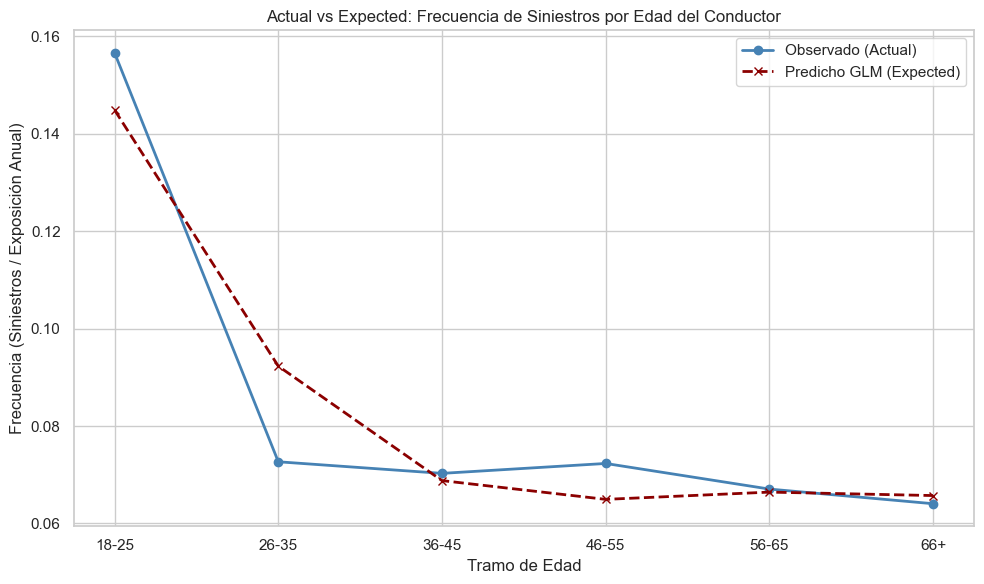

In [9]:
df_eval = df_test_freq.copy()
df_eval['Pred_GLM_Count'] = pred_f_glm

bins_age = [17, 25, 35, 45, 55, 65, 100]
labels_age = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
df_eval['DrivAge_Band'] = pd.cut(df_eval['DrivAge'], bins=bins_age, labels=labels_age, right=False)

# Suma algebraica estricta por estrato
agrupado_age = df_eval.groupby('DrivAge_Band', observed=False).agg(
    Exposure=('Exposure', 'sum'),
    Actual_Claims=('ClaimNb', 'sum'),
    Expected_Claims=('Pred_GLM_Count', 'sum')
).reset_index()

agrupado_age['Actual_Freq'] = agrupado_age['Actual_Claims'] / agrupado_age['Exposure']
agrupado_age['Expected_Freq'] = agrupado_age['Expected_Claims'] / agrupado_age['Exposure']

plt.figure(figsize=(10, 6))
plt.plot(agrupado_age['DrivAge_Band'], agrupado_age['Actual_Freq'], marker='o', 
         color='steelblue', linewidth=2, label='Observado (Actual)')
plt.plot(agrupado_age['DrivAge_Band'], agrupado_age['Expected_Freq'], marker='x', 
         color='darkred', linestyle='--', linewidth=2, label='Predicho GLM (Expected)')

plt.title('Actual vs Expected: Frecuencia de Siniestros por Edad del Conductor')
plt.xlabel('Tramo de Edad')
plt.ylabel('Frecuencia (Siniestros / Exposición Anual)')
plt.legend()
plt.tight_layout()
plt.show()

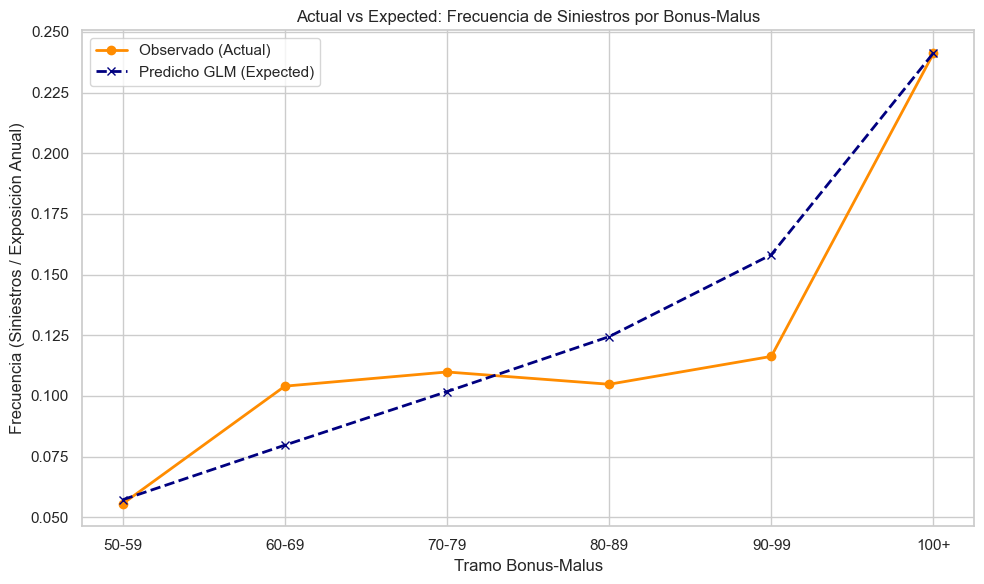

In [10]:
bins_bm = [50, 60, 70, 80, 90, 100, 250]
labels_bm = ['50-59', '60-69', '70-79', '80-89', '90-99', '100+']
df_eval['BM_Band'] = pd.cut(df_eval['BonusMalus'], bins=bins_bm, labels=labels_bm, right=False)

agrupado_bm = df_eval.groupby('BM_Band', observed=False).agg(
    Exposure=('Exposure', 'sum'),
    Actual_Claims=('ClaimNb', 'sum'),
    Expected_Claims=('Pred_GLM_Count', 'sum')
).reset_index()

agrupado_bm['Actual_Freq'] = agrupado_bm['Actual_Claims'] / agrupado_bm['Exposure']
agrupado_bm['Expected_Freq'] = agrupado_bm['Expected_Claims'] / agrupado_bm['Exposure']

plt.figure(figsize=(10, 6))
plt.plot(agrupado_bm['BM_Band'], agrupado_bm['Actual_Freq'], marker='o', 
         color='darkorange', linewidth=2, label='Observado (Actual)')
plt.plot(agrupado_bm['BM_Band'], agrupado_bm['Expected_Freq'], marker='x', 
         color='navy', linestyle='--', linewidth=2, label='Predicho GLM (Expected)')

plt.title('Actual vs Expected: Frecuencia de Siniestros por Bonus-Malus')
plt.xlabel('Tramo Bonus-Malus')
plt.ylabel('Frecuencia (Siniestros / Exposición Anual)')
plt.legend()
plt.tight_layout()
plt.show()

#### Curva de Lift (Poder de Discriminación Tarifaria)
Este gráfico es la prueba empírica definitiva del modelo tarifario. Ordenamos secuencialmente todas las pólizas de la cartera de prueba desde el riesgo más bajo predicho hasta el riesgo más alto predicho, subdividiéndolas en deciles de exposición. 
Un modelo con un alto poder de separación mostrará una curva monótonamente creciente, indicando que las primas más caras serán cobradas efectivamente a la cohorte que incurrirá en la mayor densidad de siniestros.

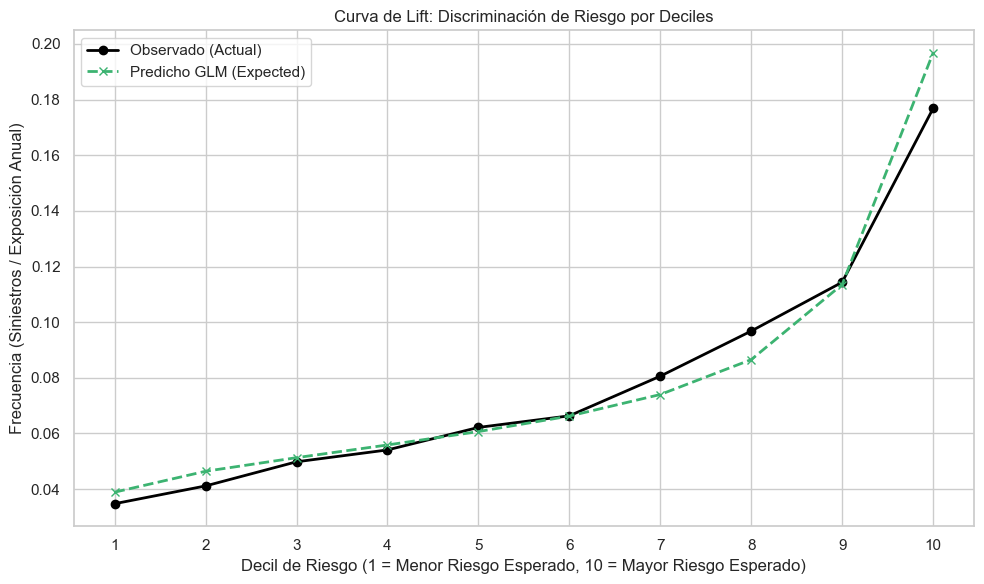

In [11]:
df_eval['Pred_Rate'] = df_eval['Pred_GLM_Count'] / df_eval['Exposure']

# Partición por cuantiles de riesgo (Deciles)
df_eval['Decile'] = pd.qcut(df_eval['Pred_Rate'], q=10, labels=False, duplicates='drop') + 1

agrupado_lift = df_eval.groupby('Decile').agg(
    Exposure=('Exposure', 'sum'),
    Actual_Claims=('ClaimNb', 'sum'),
    Expected_Claims=('Pred_GLM_Count', 'sum')
).reset_index()

agrupado_lift['Actual_Freq'] = agrupado_lift['Actual_Claims'] / agrupado_lift['Exposure']
agrupado_lift['Expected_Freq'] = agrupado_lift['Expected_Claims'] / agrupado_lift['Exposure']

plt.figure(figsize=(10, 6))
plt.plot(agrupado_lift['Decile'], agrupado_lift['Actual_Freq'], marker='o', 
         color='black', linewidth=2, label='Observado (Actual)')
plt.plot(agrupado_lift['Decile'], agrupado_lift['Expected_Freq'], marker='x', 
         color='mediumseagreen', linestyle='--', linewidth=2, label='Predicho GLM (Expected)')

plt.title('Curva de Lift: Discriminación de Riesgo por Deciles')
plt.xlabel('Decil de Riesgo (1 = Menor Riesgo Esperado, 10 = Mayor Riesgo Esperado)')
plt.ylabel('Frecuencia (Siniestros / Exposición Anual)')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

## 6. Conclusión Ejecutiva y Dictamen Tarifario
El análisis exhaustivo de la base MTPL concluye que **el riesgo en esta cartera de seguros está fundamentado matemáticamente en la frecuencia de siniestros, y no en la severidad individual.**

1. **Monto Base:** La severidad ha demostrado ser altamente estocástica (ruido aleatorio); por ello, la tarifa incorporará una prima base unificada para cubrir la esperanza del costo de severidad medio, evitando la sobreparametrización (overfitting).
2. **Tarificación de Precisión:** La frecuencia, por otro lado, exhibe una estructura causal predecible y altamente elástica. Factores estructurales como el Sistema de Bonus-Malus, la Densidad Poblacional y la Edad del Vehículo tienen un p-valor exacto del 0.00%, probando su relevancia. 
3. **Suficiencia de Prima:** Los modelos desarrollados proyectan la esperanza de ocurrencia con un desvío (ratio de equilibrio) conservador entre +1.4% y +1.8%, protegiendo financieramente la solvencia de la reserva técnica y asegurando un poder de discriminación (demostrado en la Curva de Lift) idóneo para competir sin riesgo de selección adversa.